In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv("/content/insurance (1).csv")

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# EDA

df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
numeric_columns = [ 'age' , 'bmi' , 'children' , 'charges']

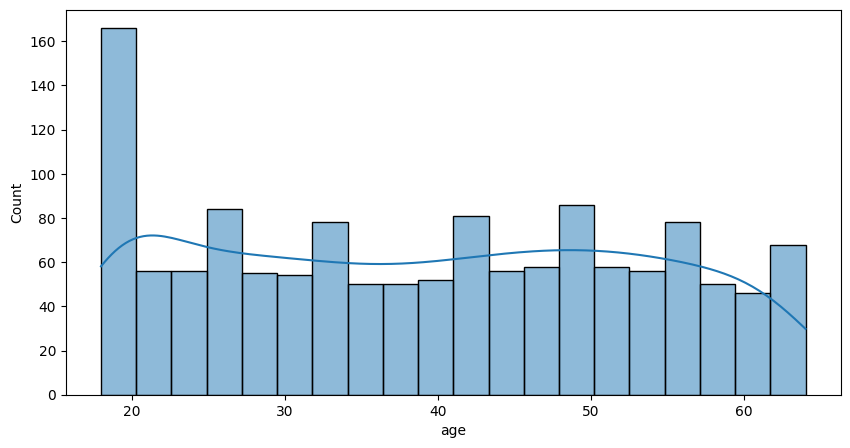

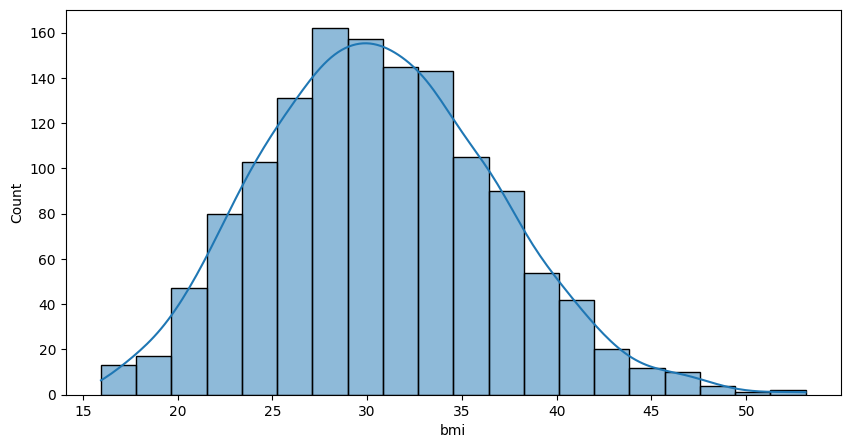

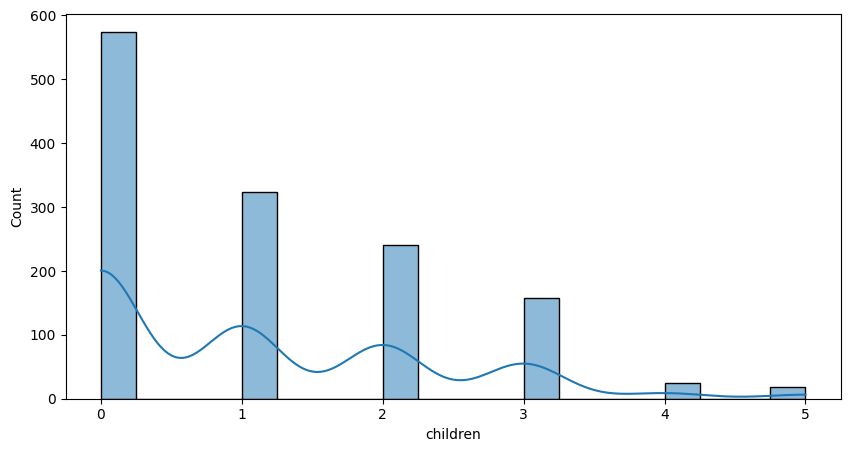

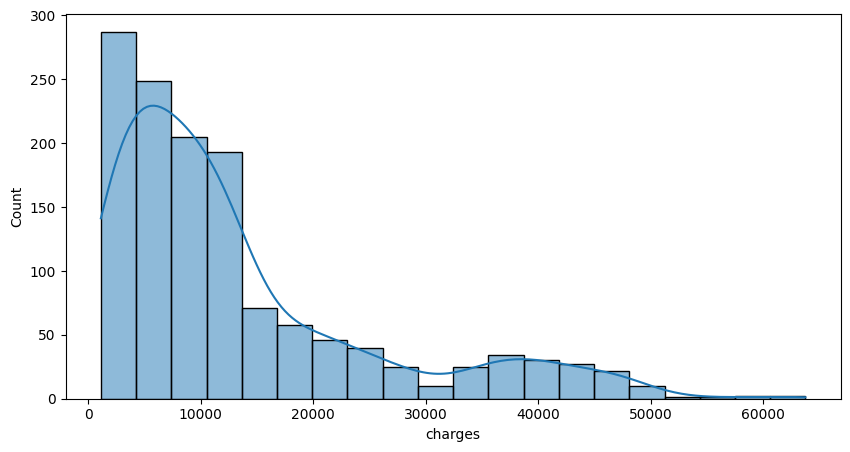

In [ ]:
for col in numeric_columns:
  plt.figure(figsize=(10,5))
  sns.histplot(df[col] , kde=True , bins=20)

<Axes: xlabel='children', ylabel='count'>

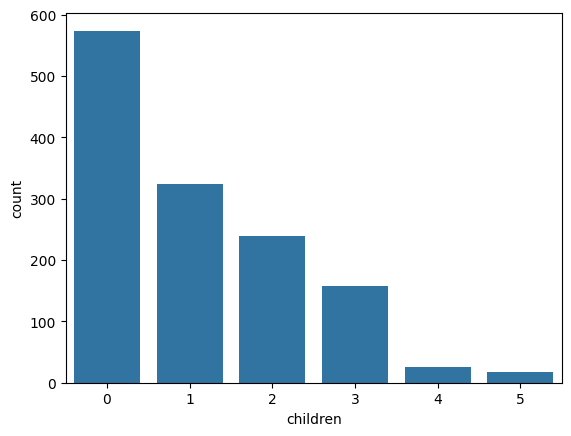

In [ ]:
# categorical_columns = ['c']
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

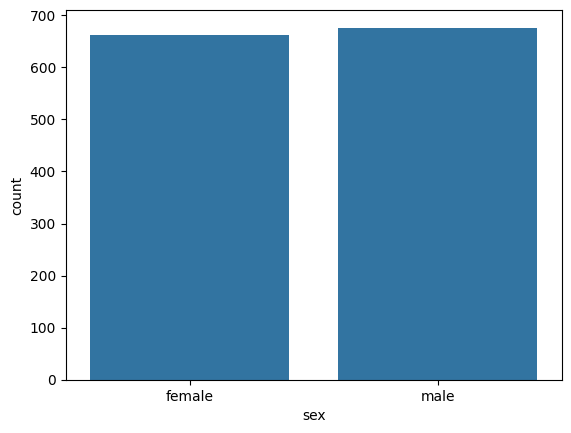

In [ ]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

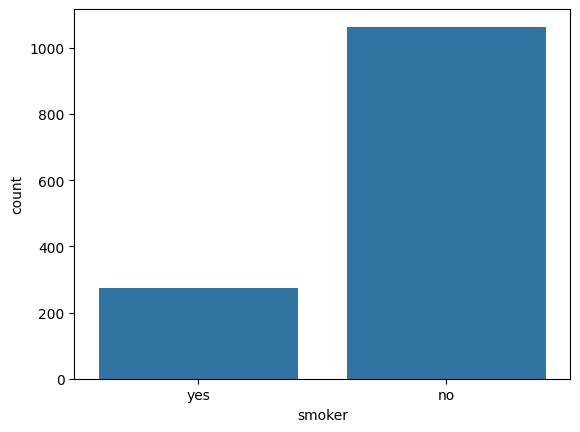

In [ ]:
sns.countplot(x=df['smoker'])

In [ ]:
df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8434.268298
yes,32050.231832


smker person have pay high amount for insurenace

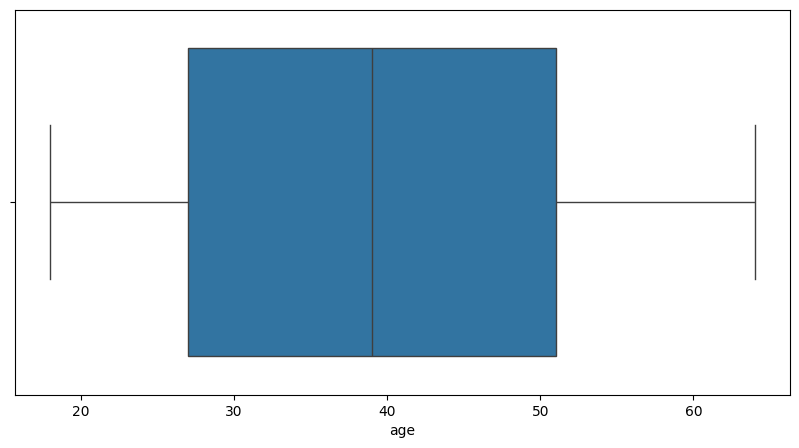

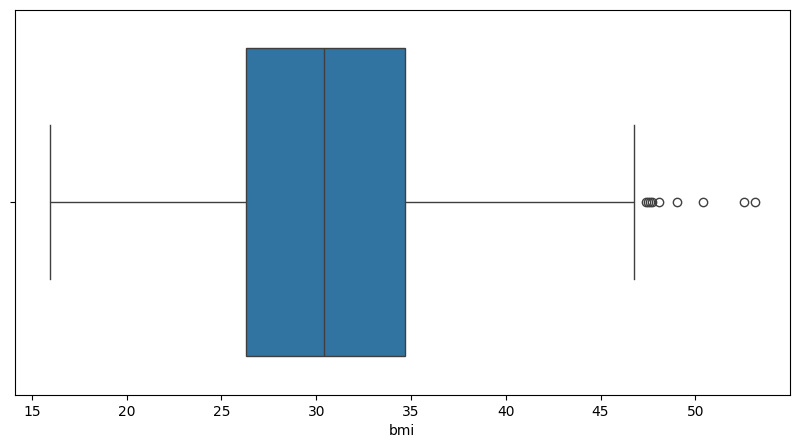

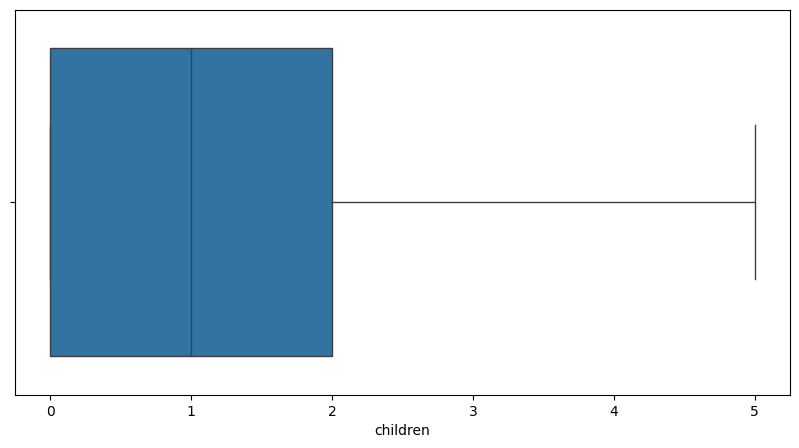

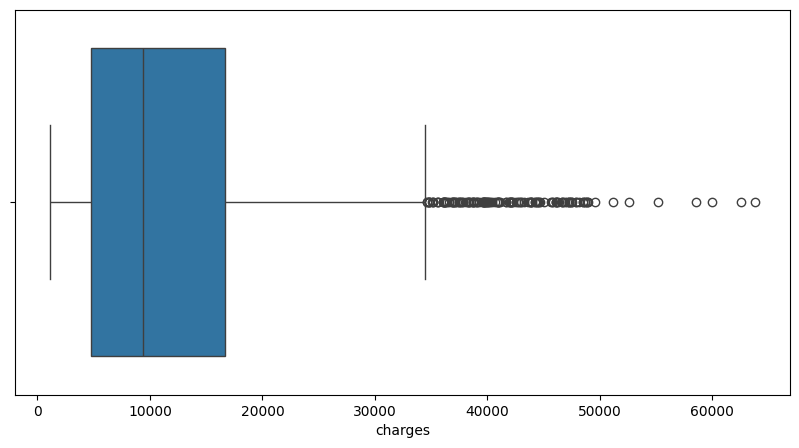

In [ ]:
for col in numeric_columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(x =df[col])

##check heatmap

<Axes: >

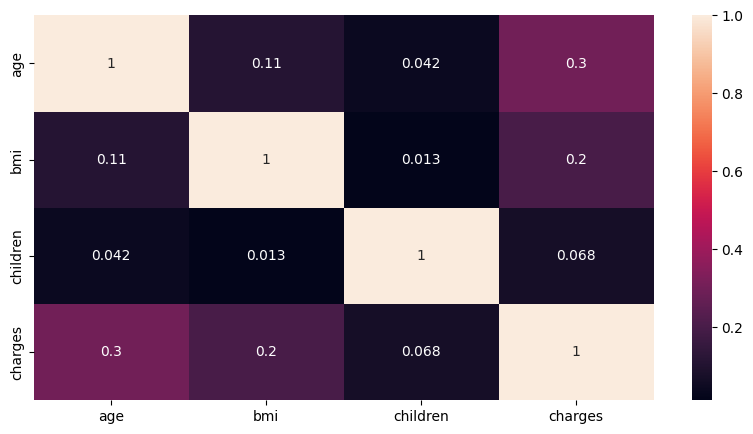

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True) , annot=True)

#Data cleaning and preprocessing


all data alredy cleaned
if not clearn we will do

#IF datasets not cleaned we will performe these steps

In [ ]:
df_cleaned= df.copy()

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df_cleaned.drop_duplicates(inplace=True)

In [ ]:
df_cleaned.shape

(1337, 7)

there are one duplicate value

In [ ]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
#For checking values

df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [ ]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [ ]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


Converting Male into 0 and female into 1


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# # using lebel encoding
df_cleaned['is_female'] = df_cleaned["is_female"].map({"male":0,'female':1})
df_cleaned['is_smoker'] = df_cleaned['is_smoker'].map({"yes":1 , 'no':0})


In [ ]:
# df_cleaned['is_smoker'] = df['smoker']
# df_cleaned['is_female'] = df['sex']

In [ ]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
                           } , inplace=True)


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned , columns=['region'] )

In [ ]:
# df_cleaned.info()
df_cleaned.head()
# df_cleaned.replace({"yes":1,"no":0})

,age,bmi,children,charges,is_smoker,is_female,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,False,False,False,True
1,18,33.770,1,1725.55230,0,0,False,False,True,False
2,28,33.000,3,4449.46200,0,0,False,False,True,False
3,33,22.705,0,21984.47061,0,0,False,True,False,False
4,32,28.880,0,3866.85520,0,0,False,True,False,False


In [ ]:
df_cleaned.columns

Index(['age', 'bmi', 'children', 'charges', 'is_smoker1', 'is_smoker',
       'is_female', 'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')

In [ ]:
df_cleaned.astype(int)

,age,bmi,children,charges,is_smoker,is_female,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,1,1,0,0,0,1
1,18,33,1,1725,0,0,0,0,1,0
2,28,33,3,4449,0,0,0,0,1,0
3,33,22,0,21984,0,0,0,1,0,0
4,32,28,0,3866,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,0,0,0,1,0,0
1334,18,31,0,2205,0,1,1,0,0,0
1335,18,36,0,1629,0,1,0,0,1,0
1336,21,25,0,2007,0,1,0,0,0,1


<Axes: >

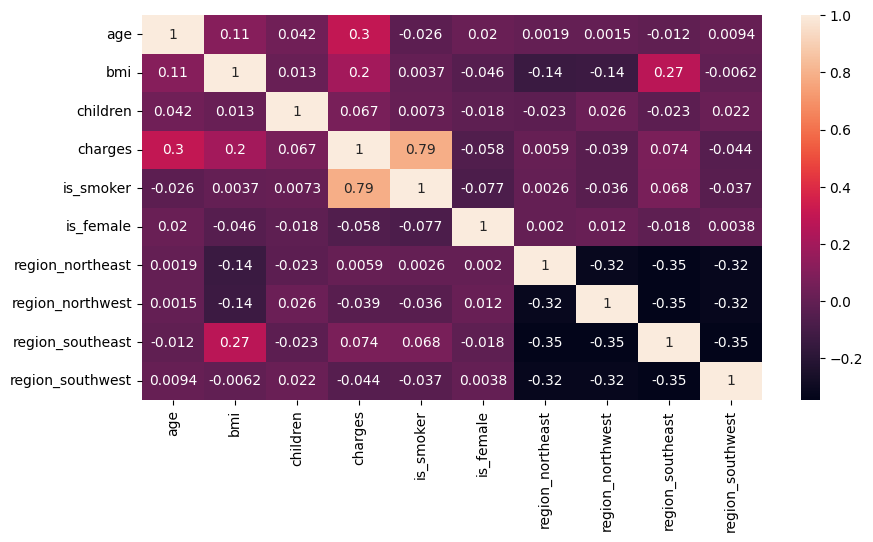

In [ ]:
plt.figure(figsize = (10,5))
sns.heatmap(df_cleaned.corr() , annot=True)

#Feature Enginnering and Extrecting

In [ ]:
df_cleaned['bmi_category'] = pd.cut(df['bmi'] , bins=[0 , 18.5 , 24.9 , 29.9 ,float('inf')]
                                    , labels=['underweight' , 'normal' , 'overweight' , 'obese'])


In [ ]:
df_cleaned.head()

,age,bmi,children,charges,is_smoker,is_female,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,27.900,0,16884.92400,1,1,False,False,False,True,overweight
1,18,33.770,1,1725.55230,0,0,False,False,True,False,obese
2,28,33.000,3,4449.46200,0,0,False,False,True,False,obese
3,33,22.705,0,21984.47061,0,0,False,True,False,False,normal
4,32,28.880,0,3866.85520,0,0,False,True,False,False,overweight


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned , columns=['bmi_category'] , drop_first=True)

In [ ]:
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned

,age,bmi,children,charges,is_smoker,is_female,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,27,0,16884,1,1,0,0,0,1,0,1,0
1,18,33,1,1725,0,0,0,0,1,0,0,0,1
2,28,33,3,4449,0,0,0,0,1,0,0,0,1
3,33,22,0,21984,0,0,0,1,0,0,1,0,0
4,32,28,0,3866,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,0,0,0,1,0,0,0,0,1
1334,18,31,0,2205,0,1,1,0,0,0,0,0,1
1335,18,36,0,1629,0,1,0,0,1,0,0,0,1
1336,21,25,0,2007,0,1,0,0,0,1,0,1,0


Data Scaling


jin method me weight par depend nhi karti unme scalling nhi karte hain

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
colm = ['age' , 'bmi' , 'children']

In [ ]:
scaler = StandardScaler()
df_cleaned[colm] = scaler.fit_transform(df_cleaned[colm])

In [ ]:
from scipy.stats import pearsonr

In [ ]:
# Pearson correlation calculation

# List of features to check agains target

select_feature = ['age', 'bmi', 'children', 'is_smoker', 'is_female',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obese']

In [ ]:
correlations = {
    feature: pearsonr(df_cleaned[feature] , df_cleaned['charges'])[0]
    for feature in select_feature
}

correlations_df = pd.DataFrame(list(correlations.items()) , columns=['Feature' , 'Pearson Correlation'])

In [ ]:
correlations_df.sort_values(by=['Pearson Correlation'] , ascending=False)

,Feature,Pearson Correlation
3,is_smoker,0.787234
0,age,0.298309
11,bmi_category_obese,0.197660
1,bmi,0.196236
7,region_southeast,0.073577
2,children,0.067390
5,region_northeast,0.005946
6,region_northwest,-0.038695
8,region_southwest,-0.043637
4,is_female,-0.058046


In [ ]:
df['charges'].agg(['min' , 'max'])


Index(['age', 'bmi', 'children', 'charges', 'is_smoker', 'is_female',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obese', 'charges_bin'],
      dtype='object')

In [ ]:
cat_feature = ['is_smoker', 'is_female',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obese']

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned["charges_bin"] = pd.qcut(df_cleaned["charges"], q=4 , labels=False )

chi2_results = {}


for col in cat_feature:
    # if col != "charges":   # skip target
      contingency = pd.crosstab(df_cleaned[col], df_cleaned["charges_bin"])
      chi2, p, _, _ = chi2_contingency(contingency)
      decision = "Reject Null (Keep Feature)" if p < alpha else "Accept Null (Drop Feature)"
      chi2_results[col] = {
          "chi2_value": chi2,
          "p_value": p,
          "Decision": decision
      }


In [ ]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value' )
chi2_df

,chi2_value,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_obese,7.654464,0.05372,Accept Null (Drop Feature)
region_northeast,6.438442,0.092122,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_category_overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


Here is my columns that i will use it  ,
also i will use bmi_category_Obese because of few different form my alpha value and in class dataset that is include

In [ ]:
final_df = df_cleaned[['age', 'bmi', 'children', 'charges', 'is_smoker', 'is_female',
       'region_southeast','bmi_category_obese']]

In [ ]:
final_df

,age,bmi,children,charges,is_smoker,is_female,region_southeast,bmi_category_obese
0,-1.440418,-0.517949,-0.909234,16884,1,1,0,0
1,-1.511647,0.462463,-0.079442,1725,0,0,1,1
2,-0.799350,0.462463,1.580143,4449,0,0,1,1
3,-0.443201,-1.334960,-0.909234,21984,0,0,0,0
4,-0.514431,-0.354547,-0.909234,3866,0,0,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,10600,0,0,0,1
1334,-1.511647,0.135659,-0.909234,2205,0,1,0,1
1335,-1.511647,0.952670,-0.909234,1629,0,1,1,1
1336,-1.297958,-0.844753,-0.909234,2007,0,1,0,0
